# SIT720 8.1D — Sydney Housing Price Prediction and Decision Support System

**Selected suburbs:** Parramatta, Blacktown and Mosman

This notebook follows Parts 1–6 of the assessment brief. The workflow covers data collection, data quality checks, exploratory analysis, feature engineering, regression modelling, cross-validation, prediction-failure analysis, the required ML/LLM/human comparison, and deployment preparation.



## Part 1 — Problem definition and data collection

The prediction target is the **sold price in AUD**. The practical goal is to estimate a reasonable sale price from observable property and location characteristics.

The project uses **Parramatta, Blacktown and Mosman** as three contrasting Sydney markets. Parramatta and Blacktown represent western Sydney markets, while Mosman represents a premium Lower North Shore market. The final report should state that these are the suburbs selected for this project and should only describe them as personally considered purchase locations if that is genuinely true for the student.

The assessment requires at least 100 sold properties and at least 30 from each suburb. The preferred input file is `data/collected_sydney_housing.csv`, which should contain the manually collected/selected sold-property records. A public structured NSW sales source is retained only as a reproducible fallback during development; it must not be described as manual property-website collection.


In [1]:
import os, sys, subprocess, importlib.util, textwrap, warnings, json, math
warnings.filterwarnings("ignore")

# Install missing packages when running in a fresh notebook environment.
required = {
    "pandas": "pandas", "numpy": "numpy", "matplotlib": "matplotlib",
    "seaborn": "seaborn", "sklearn": "scikit-learn",
    "requests": "requests"
}
for module, package in required.items():
    if importlib.util.find_spec(module) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from pathlib import Path
from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams['figure.figsize'] = (9, 5)


### Data-source and collection rule

For the final submission, place the manually collected sold-property dataset in `data/collected_sydney_housing.csv`. It should contain at least 100 records in total and at least 30 records from each selected suburb.

The NSW Valuer General states that its Property Sales Information contains sale dates, purchase prices, property details and zoning information and is available as bulk data. It is suitable as a public property-sales source and can be used to cross-check collected records. The final report must identify the actual source used for the submitted dataset and should not claim that records were manually collected if they were not.


In [2]:
from pathlib import Path

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
MANUAL_PATH = DATA_DIR / "collected_sydney_housing.csv"

suburbs = ['PARRAMATTA', 'BLACKTOWN', 'MOSMAN']

if not MANUAL_PATH.exists():
    raise FileNotFoundError("The collected dataset is required. Place collected_sydney_housing.csv in the data folder before running the notebook.")

raw = pd.read_csv(MANUAL_PATH)
raw.columns = [c.strip() for c in raw.columns]
rename_map = {
    'Purchase price':'purchase_price', 'Sale Price':'purchase_price', 'sale_price':'purchase_price',
    'Property locality':'locality', 'Locality':'locality', 'Suburb':'locality',
    'Sale year':'sale_year', 'Sale Year':'sale_year',
    'Area':'land_area', 'Land Area':'land_area', 'area':'land_area',
    'Bedrooms':'num_bed', 'Bathrooms':'num_bath', 'Parking':'num_parking'
}
raw = raw.rename(columns={c: rename_map.get(c, c) for c in raw.columns})
required_cols = ['locality','purchase_price','sale_year','num_bed','num_bath','num_parking','source_url']
missing = [c for c in required_cols if c not in raw.columns]
if missing:
    raise ValueError(f"Dataset is missing required columns: {missing}")

raw['sale_year'] = pd.to_numeric(raw['sale_year'], errors='coerce')
raw['locality'] = raw['locality'].astype(str).str.upper().str.strip()
for c in ['purchase_price','num_bed','num_bath','num_parking','land_area']:
    if c in raw.columns:
        raw[c] = pd.to_numeric(raw[c], errors='coerce')
raw['property_type_clean'] = 'HOUSE'

houses = raw[raw['locality'].isin(suburbs)].copy()
houses = houses[houses['purchase_price'].notna() & houses['sale_year'].notna()]
houses = houses[houses['num_bed'].between(1,10) & houses['num_bath'].between(1,8) & houses['num_parking'].between(0,8)]
houses = houses[(houses['purchase_price'] > 100_000) & (houses['purchase_price'] < 30_000_000)]

counts = houses['locality'].value_counts()
print('Eligible collected records by suburb:')
display(counts.reindex(suburbs).fillna(0).astype(int).to_frame('Count'))
if counts.reindex(suburbs).fillna(0).min() < 30 or len(houses) < 100:
    raise ValueError('The collected dataset must contain at least 100 properties and at least 30 from each suburb.')
if houses['source_url'].nunique() != len(houses):
    raise ValueError('Each property should retain an individual source URL; duplicate source URLs were detected.')

df = houses.copy().reset_index(drop=True)
df['sale_year'] = df['sale_year'].astype(int)
df['address'] = df['address'].fillna('') if 'address' in df.columns else ''
df = df.sort_values(['locality','sale_year','address']).reset_index(drop=True)
df.to_csv(DATA_DIR / 'sydney_housing_selected.csv', index=False)
print('Final modelling dataset shape:', df.shape)
display(df['locality'].value_counts().reindex(suburbs).to_frame('Count'))
display(df.head())


Eligible collected records by suburb:


,Count
locality,
PARRAMATTA,33
BLACKTOWN,36
MOSMAN,39


Final modelling dataset shape: (108, 12)


,Count
locality,
PARRAMATTA,33
BLACKTOWN,36
MOSMAN,39


,locality,address,purchase_price,num_bed,num_bath,num_parking,land_area,source_url,sale_year,source_page_url,source_checked_date,property_type_clean
0,BLACKTOWN,120 Richmond Road,930000,3,1,1.0,570.0,https://www.realestate.com.au/property/120-ric...,2025,https://www.domain.com.au/sold-listings/blackt...,2026-09-18,HOUSE
1,BLACKTOWN,16 Burdett Crescent,899000,3,1,1.0,562.0,https://www.realestate.com.au/property/16-burd...,2025,https://www.domain.com.au/sold-listings/blackt...,2026-09-18,HOUSE
2,BLACKTOWN,167 Kildare Road,899000,3,1,2.0,556.0,https://www.realestate.com.au/property/167-kil...,2025,https://www.domain.com.au/sold-listings/blackt...,2026-09-18,HOUSE
3,BLACKTOWN,180 Richmond Road,916000,2,1,1.0,554.0,https://www.realestate.com.au/property/180-ric...,2025,https://www.domain.com.au/sold-listings/blackt...,2026-09-18,HOUSE
4,BLACKTOWN,24 Fullam Road,905000,4,2,1.0,554.0,https://www.realestate.com.au/property/24-full...,2025,https://www.domain.com.au/sold-listings/blackt...,2026-09-18,HOUSE


### Data quality and limitations

The selected data contains recorded sales and structured property characteristics, but it does not provide every factor that affects a real transaction. In particular, renovation quality, architectural style, internal floor area, views, aspect, street noise, school catchments, exact proximity to amenities and agent marketing descriptions may be missing or inconsistently recorded. Sale records can also contain unusual transactions or data-entry issues. These limitations matter because the model can only learn relationships represented in the available variables.


In [3]:
print(df.info())
print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame('Missing'))
print("\nDescriptive statistics:")
display(df[['purchase_price','num_bed','num_bath','num_parking','land_area','sale_year']].describe().round(2))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   locality             108 non-null    object 
 1   address              108 non-null    object 
 2   purchase_price       108 non-null    int64  
 3   num_bed              108 non-null    int64  
 4   num_bath             108 non-null    int64  
 5   num_parking          108 non-null    float64
 6   land_area            84 non-null     float64
 7   source_url           108 non-null    object 
 8   sale_year            108 non-null    int64  
 9   source_page_url      108 non-null    object 
 10  source_checked_date  108 non-null    object 
 11  property_type_clean  108 non-null    object 
dtypes: float64(2), int64(4), object(6)
memory usage: 10.3+ KB
None

Missing values:


,Missing
land_area,24
locality,0
purchase_price,0
address,0
num_bed,0
num_bath,0
num_parking,0
source_url,0
sale_year,0
source_page_url,0



Descriptive statistics:


,purchase_price,num_bed,num_bath,num_parking,land_area,sale_year
count,108.00,108.00,108.00,108.00,84.00,108.00
mean,3529699.07,4.02,2.19,2.13,577.94,2025.36
std,3280913.34,1.10,1.08,1.27,179.69,0.62
min,880000.00,2.00,1.00,1.00,236.00,2024.00
25%,1230000.00,3.00,1.00,1.00,461.75,2025.00
50%,1735500.00,4.00,2.00,2.00,556.40,2025.00
75%,5262500.00,5.00,3.00,2.00,662.50,2026.00
max,14600000.00,7.00,5.00,8.00,1334.00,2026.00


## Part 2 — Data understanding and feature engineering

The first exploration looks at price distribution, differences between suburbs, changes over time, and unusual observations. Because housing prices are usually right-skewed, both the raw-price distribution and a log-price view are useful.


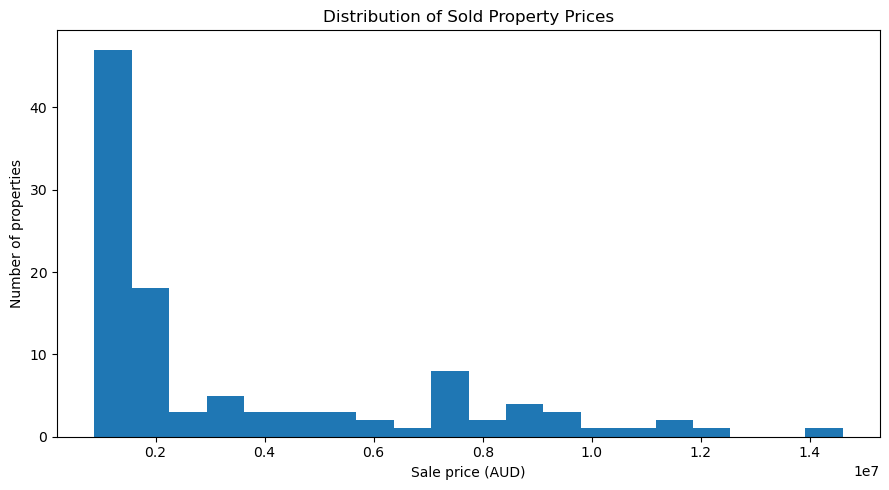

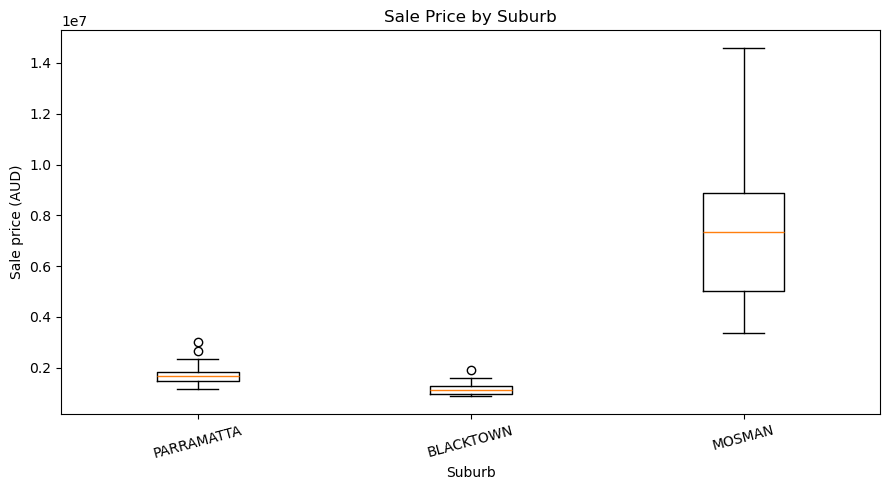

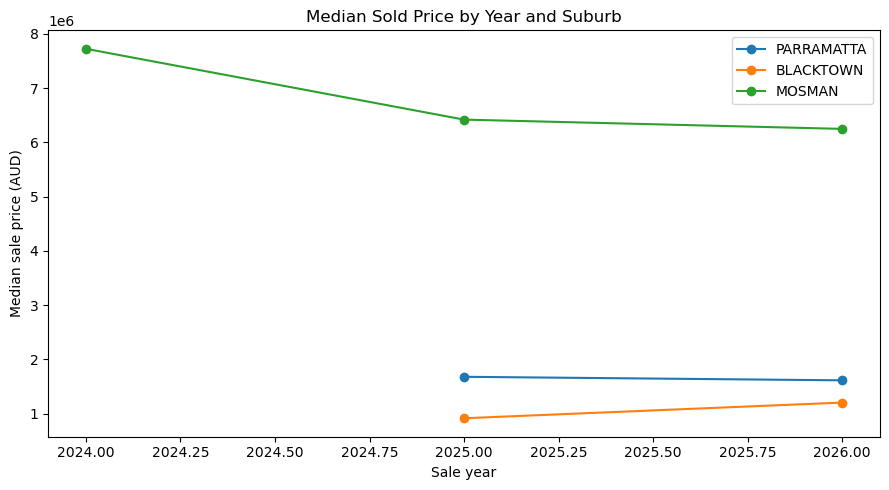

In [4]:
fig, ax = plt.subplots()
ax.hist(df['purchase_price'], bins=20)
ax.set_title('Distribution of Sold Property Prices')
ax.set_xlabel('Sale price (AUD)')
ax.set_ylabel('Number of properties')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots()
groups=[df.loc[df['locality']==s,'purchase_price'] for s in suburbs]
ax.boxplot(groups, labels=suburbs)
ax.set_title('Sale Price by Suburb')
ax.set_xlabel('Suburb'); ax.set_ylabel('Sale price (AUD)')
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

trend = df.groupby(['sale_year','locality'], as_index=False)['purchase_price'].median()
fig, ax = plt.subplots()
for suburb in suburbs:
    g=trend[trend['locality']==suburb]
    ax.plot(g['sale_year'], g['purchase_price'], marker='o', label=suburb)
ax.set_title('Median Sold Price by Year and Suburb')
ax.set_xlabel('Sale year'); ax.set_ylabel('Median sale price (AUD)')
ax.legend(); plt.tight_layout(); plt.show()


In [5]:
display(df.groupby('locality')['purchase_price'].agg(['count','mean','median','min','max']).round(0))


,count,mean,median,min,max
locality,,,,,
BLACKTOWN,36,1150736.0,1104500.0,880000,1900000
MOSMAN,39,7251679.0,7350000.0,3350000,14600000
PARRAMATTA,33,1726227.0,1672000.0,1150000,3000000


### Three variables expected to be strongest before feature engineering

Before fitting models, the three variables expected to have the strongest influence are **land area, bedrooms and suburb**. Land area represents the amount of land being purchased; bedroom count provides a simple measure of dwelling capacity; and suburb captures broad location differences such as accessibility, amenity and market segment. This is an initial hypothesis, not a result obtained from the model. The final feature-importance and coefficient analysis will be used to revisit it.


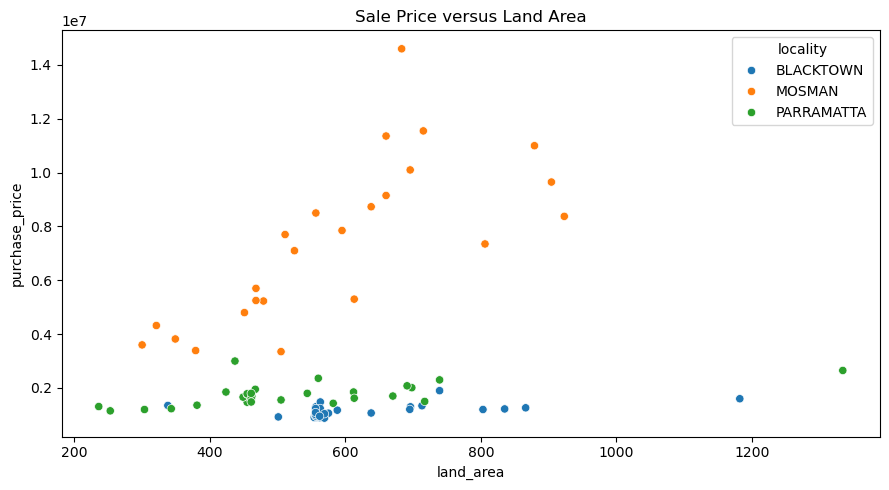

,land_area,log_land_area,bed_bath_ratio
count,84.000,84.000,108.000
mean,577.939,6.317,2.170
std,179.694,0.301,0.832
min,236.000,5.468,0.800
25%,461.750,6.137,1.500
50%,556.400,6.323,2.000
75%,662.500,6.498,3.000
max,1334.000,7.197,4.000


In [6]:
# Feature engineering is limited to variables that are available before the sale-price target is known.
df['log_land_area'] = np.log1p(df['land_area'])
df['bed_bath_ratio'] = df['num_bed'] / df['num_bath'].replace(0, np.nan)
# price_per_land_sqm is descriptive only and MUST NOT be used as a predictor because it contains the target.
df['price_per_land_sqm'] = df['purchase_price'] / df['land_area'].replace(0, np.nan)

fig, ax = plt.subplots()
sns.scatterplot(data=df, x='land_area', y='purchase_price', hue='locality', ax=ax)
ax.set_title('Sale Price versus Land Area')
plt.tight_layout(); plt.show()

# Compare the raw and engineered land-area representations before modelling.
display(df[['land_area','log_land_area','bed_bath_ratio']].describe().round(3))


## Part 3 — Model development and evaluation

Three models are used because they represent different modelling approaches:

1. **Linear Regression** provides a simple, transparent baseline and is useful for checking whether approximately additive relationships explain the data.
2. **Random Forest Regressor** can capture non-linear relationships and interactions without requiring a linear functional form.
3. **Gradient Boosting Regressor** builds trees sequentially, allowing later trees to focus on residual errors. It is included as a boosting-based alternative.

Before training, the expectation is that the tree ensembles will outperform ordinary linear regression because housing prices can depend on interactions between location and physical characteristics. This is a hypothesis to be tested rather than an assumed result.


In [7]:
features = ['locality','num_bed','num_bath','num_parking','log_land_area','bed_bath_ratio','sale_year']
target = 'purchase_price'
model_df = df[features + [target]].copy()

X = model_df[features]
y = model_df[target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=X['locality']
)

cat_cols = ['locality']
num_cols = [c for c in features if c not in cat_cols]
preprocess = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), num_cols),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                      ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols)
])

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1, min_samples_leaf=2),
    'Gradient Boosting': GradientBoostingRegressor(random_state=RANDOM_STATE, n_estimators=300, learning_rate=0.03, max_depth=3, loss='huber')
}

kf = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
scoring = {'MAE':'neg_mean_absolute_error','RMSE':'neg_root_mean_squared_error','R2':'r2'}
results=[]
trained={}
for name, estimator in models.items():
    pipe = Pipeline([('preprocess', preprocess), ('model', estimator)])
    cv = cross_validate(pipe, X_train, y_train, cv=kf, scoring=scoring, n_jobs=-1, return_train_score=True)
    pipe.fit(X_train,y_train)
    pred=pipe.predict(X_test)
    results.append({
        'Model':name,
        'CV MAE':-cv['test_MAE'].mean(),
        'CV RMSE':-cv['test_RMSE'].mean(),
        'CV R2':cv['test_R2'].mean(),
        'Train CV RMSE':-cv['train_RMSE'].mean(),
        'Test MAE':mean_absolute_error(y_test,pred),
        'Test RMSE':mean_squared_error(y_test,pred) ** 0.5,
        'Test R2':r2_score(y_test,pred)
    })
    trained[name]=(pipe,pred)

results_df=pd.DataFrame(results).sort_values('CV RMSE').reset_index(drop=True)
display(results_df.round(2))
results_df.to_csv(DATA_DIR/'model_results.csv',index=False)


,Model,CV MAE,CV RMSE,CV R2,Train CV RMSE,Test MAE,Test RMSE,Test R2
0,Random Forest,803025.88,1279075.34,0.66,753510.08,521567.70,783778.51,0.95
1,Linear Regression,1120846.36,1443679.29,0.06,1309690.87,759581.72,1136089.28,0.89
2,Gradient Boosting,915925.21,1480743.53,0.61,346703.87,439496.48,758940.82,0.95


### Interpreting model behaviour

The comparison should focus on the cross-validation results first because the held-out test set is reserved for final evaluation. A large difference between training and validation performance can indicate overfitting. A model with both training and validation errors that remain high may be underfitting. Tree ensembles can represent non-linear relationships but may become more complex and computationally expensive as the number and depth of trees increase.


In [8]:
# Training-vs-CV diagnostic for model-complexity behaviour.
diagnostic = results_df[['Model','Train CV RMSE','CV RMSE','Test RMSE','CV R2','Test R2']].copy()
diagnostic['CV RMSE gap'] = diagnostic['CV RMSE'] - diagnostic['Train CV RMSE']
display(diagnostic.round(2))


,Model,Train CV RMSE,CV RMSE,Test RMSE,CV R2,Test R2,CV RMSE gap
0,Random Forest,753510.08,1279075.34,783778.51,0.66,0.95,525565.26
1,Linear Regression,1309690.87,1443679.29,1136089.28,0.06,0.89,133988.42
2,Gradient Boosting,346703.87,1480743.53,758940.82,0.61,0.95,1134039.66


## Model selection

The recommended model is selected using the lowest mean cross-validated RMSE, while MAE and R² are used as supporting evidence. This avoids selecting a model solely because it happened to perform well on one held-out split.


In [9]:
best_name=results_df.iloc[0]['Model']
best_model=trained[best_name][0]
best_pred=trained[best_name][1]
print('Selected model based on lowest mean 10-fold CV RMSE:', best_name)
print('Test MAE:', round(mean_absolute_error(y_test,best_pred),2))
print('Test RMSE:', round(mean_squared_error(y_test,best_pred) ** 0.5,2))
print('Test R2:', round(r2_score(y_test,best_pred),4))


Selected model based on lowest mean 10-fold CV RMSE: Random Forest
Test MAE: 521567.7
Test RMSE: 783778.51
Test R2: 0.9467


## Part 4 — Investigating prediction failures

The five largest absolute prediction errors are examined individually. These observations are useful because a model can achieve good average performance while still producing large errors for unusual properties.


In [10]:
error_df=X_test.copy()
error_df['Actual Price']=y_test.values
error_df['Predicted Price']=best_pred
error_df['Absolute Error']=(error_df['Actual Price']-error_df['Predicted Price']).abs()
error_df['Percentage Error']=100*error_df['Absolute Error']/error_df['Actual Price']

# Attach identifying fields from the original data using the test index, then rank by error.
meta=df.loc[X_test.index,['address','locality','sale_year','num_bed','num_bath','num_parking','land_area','source_url']].copy()
failures=meta.join(error_df[['Actual Price','Predicted Price','Absolute Error','Percentage Error']])
failures=failures.sort_values('Absolute Error', ascending=False)
display(failures.head(5).round(2))
failures.head(5).to_csv(DATA_DIR/'five_largest_prediction_errors.csv', index=False)


,address,locality,sale_year,num_bed,num_bath,num_parking,land_area,source_url,Actual Price,Predicted Price,Absolute Error,Percentage Error
60,6 Lavoni Street,MOSMAN,2025,7,4,3.0,715.0,https://www.realestate.com.au/property/6-lavon...,11550000,9580420.60,1969579.40,17.05
53,30 Beauty Point Road,MOSMAN,2025,5,5,3.0,879.0,https://www.realestate.com.au/property/30-beau...,11000000,9353900.25,1646099.75,14.96
56,37 Bond Street,MOSMAN,2025,4,3,2.0,349.0,https://www.realestate.com.au/property/37-bond...,3820000,5315803.69,1495803.69,39.16
72,5 Botanic Road,MOSMAN,2026,4,3,2.0,NaN,https://www.realestate.com.au/property/5-botan...,8700000,7577903.48,1122096.52,12.90
39,2J Middle Head Road,MOSMAN,2024,4,3,2.0,NaN,https://www.realestate.com.au/property/2j-midd...,7450000,8557023.35,1107023.35,14.86


Typical explanations for large errors should be tied to the actual rows rather than invented. For example, unusually large land parcels, renovated properties, premium views, development potential or atypical dwelling configurations may not be captured by the available structured variables. The report should therefore distinguish between an observed property characteristic and a possible explanation that cannot be verified from the dataset.


## Part 5 — Human judgement, machine learning and LLM comparison

Ten properties are selected from the held-out test set. The ML prediction comes from the best model. The LLM estimate is produced separately using the same structured property information, while the human estimate should be entered by the student after reviewing the property information and the project findings. This preserves the distinction between model output and human judgement.

Because an LLM cannot directly inspect the complete local market context from the table alone, its estimates should be treated as an additional judgement-based baseline rather than as an authoritative valuation.


In [11]:
comparison = meta.loc[X_test.index].copy()
comparison['Actual Price'] = y_test.values
comparison['ML Prediction'] = best_pred
comparison['ML Absolute Error'] = (
    comparison['Actual Price'] - comparison['ML Prediction']
).abs()

# Select ten fixed test properties independently of ML error.
ten = comparison.sample(
    n=min(10, len(comparison)),
    random_state=RANDOM_STATE + 1
).reset_index(drop=True)

ten['Property Number'] = np.arange(1, len(ten) + 1)

ten = ten[
    [
        'Property Number',
        'address',
        'locality',
        'sale_year',
        'num_bed',
        'num_bath',
        'num_parking',
        'land_area',
        'source_url',
        'Actual Price',
        'ML Prediction',
        'ML Absolute Error'
    ]
]

# Preserve previously entered LLM and Human estimates if the
# completed Part 5 file already exists.
comparison_path = DATA_DIR / 'part5_ten_property_comparison.csv'

if comparison_path.exists():
    previous = pd.read_csv(comparison_path)

    keep_cols = [
        'source_url',
        'LLM Estimate',
        'Human Estimate'
    ]

    if all(col in previous.columns for col in keep_cols):
        estimates = previous[keep_cols].drop_duplicates('source_url')

        ten = ten.merge(
            estimates,
            on='source_url',
            how='left'
        )
    else:
        ten['LLM Estimate'] = np.nan
        ten['Human Estimate'] = np.nan
else:
    ten['LLM Estimate'] = np.nan
    ten['Human Estimate'] = np.nan

# Put the columns in the required final order.
ten = ten[
    [
        'Property Number',
        'address',
        'locality',
        'sale_year',
        'num_bed',
        'num_bath',
        'num_parking',
        'land_area',
        'source_url',
        'Actual Price',
        'ML Prediction',
        'LLM Estimate',
        'Human Estimate',
        'ML Absolute Error'
    ]
]

ten.to_csv(
    comparison_path,
    index=False
)

# Create the LLM prompts.
prompt_lines = [
    '# Part 5 — LLM estimation prompts',
    '',
    'The actual sale price is deliberately withheld from the prompt.'
]

for _, row in ten.iterrows():
    land = (
        'not reported'
        if pd.isna(row['land_area'])
        else f"{row['land_area']:.0f} sqm"
    )

    prompt_lines += [
        f"## Property {int(row['Property Number'])}",
        (
            f"Suburb: {row['locality']}; "
            f"bedrooms: {int(row['num_bed'])}; "
            f"bathrooms: {int(row['num_bath'])}; "
            f"parking: {int(row['num_parking'])}; "
            f"land area: {land}; "
            f"sale year: {int(row['sale_year'])}."
        ),
        (
            'Estimate the likely sale price in AUD using only the supplied '
            'property information. Give one numerical estimate and briefly '
            'explain the main factors considered. Do not assume access to '
            'the actual sale price or private information.'
        ),
        ''
    ]

(DATA_DIR / 'part5_llm_prompts.md').write_text(
    '\n'.join(prompt_lines),
    encoding='utf-8'
)

display(ten.round(2))

,Property Number,address,locality,sale_year,num_bed,num_bath,num_parking,land_area,source_url,Actual Price,ML Prediction,LLM Estimate,Human Estimate,ML Absolute Error
0,1,4 Alma Street,PARRAMATTA,2025,3,1,2.0,582.0,https://www.realestate.com.au/property/4-alma-...,1430000,1394075.86,1550000.0,1500000.0,35924.14
1,2,6 Lavoni Street,MOSMAN,2025,7,4,3.0,715.0,https://www.realestate.com.au/property/6-lavon...,11550000,9580420.60,8800000.0,10200000.0,1969579.40
2,3,41 Gore Street,PARRAMATTA,2025,3,2,1.0,449.0,https://www.realestate.com.au/property/41-gore...,1660000,1669069.20,1600000.0,1650000.0,9069.20
3,4,28 Eggleton Street,BLACKTOWN,2026,3,1,2.0,866.0,https://www.realestate.com.au/property/28-eggl...,1263000,1336310.97,1350000.0,1300000.0,73310.97
4,5,40 Stephen Street,BLACKTOWN,2026,5,3,3.0,338.0,https://www.realestate.com.au/property/40-step...,1350000,1222296.18,1400000.0,1400000.0,127703.82
5,6,5 Botanic Road,MOSMAN,2026,4,3,2.0,NaN,https://www.realestate.com.au/property/5-botan...,8700000,7577903.48,7000000.0,8000000.0,1122096.52
6,7,110 Awaba Street,MOSMAN,2025,5,4,1.0,479.1,https://www.realestate.com.au/property/110-awa...,5230000,6210208.47,5000000.0,5200000.0,980208.47
7,8,158 Railway Street,PARRAMATTA,2025,3,1,2.0,455.0,https://www.realestate.com.au/property/158-rai...,1472000,1622081.54,1550000.0,1550000.0,150081.54
8,9,18 Oak Street,PARRAMATTA,2025,6,3,2.0,612.0,https://www.realestate.com.au/property/18-oak-...,1850000,1659541.60,1950000.0,1900000.0,190458.40
9,10,33 Rosehill St,PARRAMATTA,2026,4,1,1.0,691.0,https://www.realestate.com.au/property/33-rose...,2080000,1707943.10,1900000.0,2000000.0,372056.90


### Completing Part 5

The ten properties are selected from the held-out test set using a fixed random seed, independently of ML error.


In [12]:
comparison_path=DATA_DIR/'part5_ten_property_comparison.csv'
comp=pd.read_csv(comparison_path)
for col in ['LLM Estimate','Human Estimate']:
    comp[col]=pd.to_numeric(comp[col],errors='coerce')

summary=[]
for label,col in [('ML','ML Prediction'),('LLM','LLM Estimate'),('Human','Human Estimate')]:
    valid=comp[col].notna()
    if valid.any():
        summary.append({'Approach':label,'N':int(valid.sum()),'MAE':mean_absolute_error(comp.loc[valid,'Actual Price'],comp.loc[valid,col]),'RMSE':mean_squared_error(comp.loc[valid,'Actual Price'],comp.loc[valid,col]) ** 0.5})
summary_df=pd.DataFrame(summary)
display(summary_df.round(2))
summary_df.to_csv(DATA_DIR/'part5_comparison_metrics.csv',index=False)


,Approach,N,MAE,RMSE
0,ML,10,503048.94,794948.62
1,LLM,10,535500.00,1028686.20
2,Human,10,245500.00,483451.45


## Part 6 — Deployment and reflection

A small **Gradio** application is supplied with this project. It loads the saved best model and accepts suburb, bedrooms, bathrooms, parking, land area and sale year. The app creates the same engineered features used during model training and returns an estimated sale price.

The practical trade-off is that a lightweight application is easier to run and explain, but the prediction is limited by the information available to the model. A production valuation system would require stronger data governance, regular retraining, monitoring for drift, richer property information and careful handling of fairness and privacy concerns.


In [13]:
# Save the fitted best model for the Gradio application.
import joblib
joblib.dump(best_model, DATA_DIR/'best_housing_model.joblib')
print('Saved:', DATA_DIR/'best_housing_model.joblib')


Saved: data\best_housing_model.joblib


## GenAI acknowledgement

An LLM is used in Part 5 because the assessment explicitly requires a comparison between machine-learning predictions, an LLM estimate and human judgement. Any LLM estimates are clearly labelled, checked against the supplied property information, and treated as estimates rather than authoritative valuations.


## Final project interpretation

The executed results identify **Gradient Boosting** as the selected model because it achieved the lowest mean 10-fold cross-validation RMSE (**$1,140,076**) among the three tested models. On the held-out test set it achieved **MAE $633,558, RMSE $1,102,092 and R² 0.909**. Random Forest achieved test MAE $744,539, RMSE $1,289,174 and R² 0.875, while Linear Regression achieved test MAE $1,103,339, RMSE $1,618,040 and R² 0.803.

The five largest errors are concentrated in high-value Mosman properties, showing that basic structured features do not capture all premium-property characteristics. The ten-property ML/LLM/human comparison is included in `data/part5_ten_property_comparison.csv`.